<a href="https://colab.research.google.com/github/alviglio/AlbJupyters/blob/main/SivaGuenterPeterBook/Chapter02draft02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2: Seasonality of Runoff Through Storage - Simple Hydrological Models in R

## Introduction

Runoff seasonality is not controlled by precipitation alone. Between precipitation falling from the atmosphere and streamflow leaving a catchment, water can be delayed, stored, released, evaporated, or artificially moved by human management.

This notebook uses simple numerical models to illustrate how seasonal runoff patterns emerge from catchment storage processes. We begin with the simplest possible snow model, where winter snowfall accumulates as snow water equivalent and is released later as snowmelt. We then add a subsurface storage that receives meltwater or rainfall and releases water through runoff and evapotranspiration.

The notebook follows a step-by-step modelling approach. Each section isolates one process so that its effect can be understood clearly:

1. snow accumulation;
2. degree-day snowmelt;
3. subsurface water storage;
4. linear runoff and evapotranspiration;
5. nonlinear storage–flux relationships;
6. seasonal phase shifts between precipitation and potential evapotranspiration;
7. irrigation and artificial drainage.

At the end, the separate processes are combined into a complete conceptual water-balance model. The complete model can then be simplified by turning processes on or off, showing that the earlier models are special cases of the final model.

The goal is not to build a calibrated catchment model, but to create a transparent modelling laboratory where we can change parameters and immediately see how they affect storage, evapotranspiration, runoff, snowmelt, irrigation, and drainage.

## 1. Setup

We begin by defining a few plotting utilities and common functions. The models in this notebook are intentionally simple and are written in base R so that each calculation is visible.

In [1]:
options(repr.plot.width = 12, repr.plot.height = 8)

blue <- "#56B4E9"
orange <- "#E69F00"
green <- "#009E73"
purple <- "#984EA3"
red <- "#D55E00"

safe_min <- function(x, y) pmin(x, y)
safe_max <- function(x, y) pmax(x, y)

## 2. Snow accumulation as a storage process

In a snow-dominated catchment, winter precipitation may not become runoff immediately. Instead, it accumulates as snow water equivalent, or SWE. This creates a delay between precipitation input and water availability to the catchment.

We begin with a very simple model where snowfall accumulates during winter and no melt occurs.

In [2]:
snow_accumulation_only <- function(snowfall, SWE_0 = 0) {
  n <- length(snowfall)

  SWE <- rep(NA, n + 1)
  SWE[1] <- SWE_0

  for (t in 1:n) {
    SWE[t + 1] <- SWE[t] + snowfall[t]
  }

  data.frame(
    t = 1:n,
    snowfall = snowfall,
    SWE = SWE[-1]
  )
}

## 3. Degree-day snowmelt

We now add a temperature-controlled melt process. The degree-day approach assumes that melt increases linearly with temperature above a melt threshold.

Potential melt is:

$$
M_{pot}(t) = DDF \cdot \max(T(t) - T_m, 0)
$$

Actual melt cannot exceed the snow available:

$$
M(t) = \min(SWE(t) + P_s(t), M_{pot}(t))
$$

The snow storage update is:

$$
SWE(t+1) = SWE(t) + P_s(t) - M(t)
$$

In [3]:
snow_model <- function(
    P,
    T,
    DDF = 3,
    T_snow = 0,
    T_melt = 0,
    SWE_0 = 0
) {
  n <- length(P)

  snowfall <- ifelse(T <= T_snow, P, 0)
  rainfall <- ifelse(T > T_snow, P, 0)

  SWE <- rep(NA, n + 1)
  melt <- rep(NA, n)

  SWE[1] <- SWE_0

  for (t in 1:n) {
    potential_melt <- DDF * max(T[t] - T_melt, 0)
    snow_available <- SWE[t] + snowfall[t]

    melt[t] <- min(potential_melt, snow_available)
    SWE[t + 1] <- snow_available - melt[t]
  }

  data.frame(
    t = 1:n,
    P = P,
    T = T,
    rainfall = rainfall,
    snowfall = snowfall,
    SWE = SWE[-1],
    melt = melt
  )
}

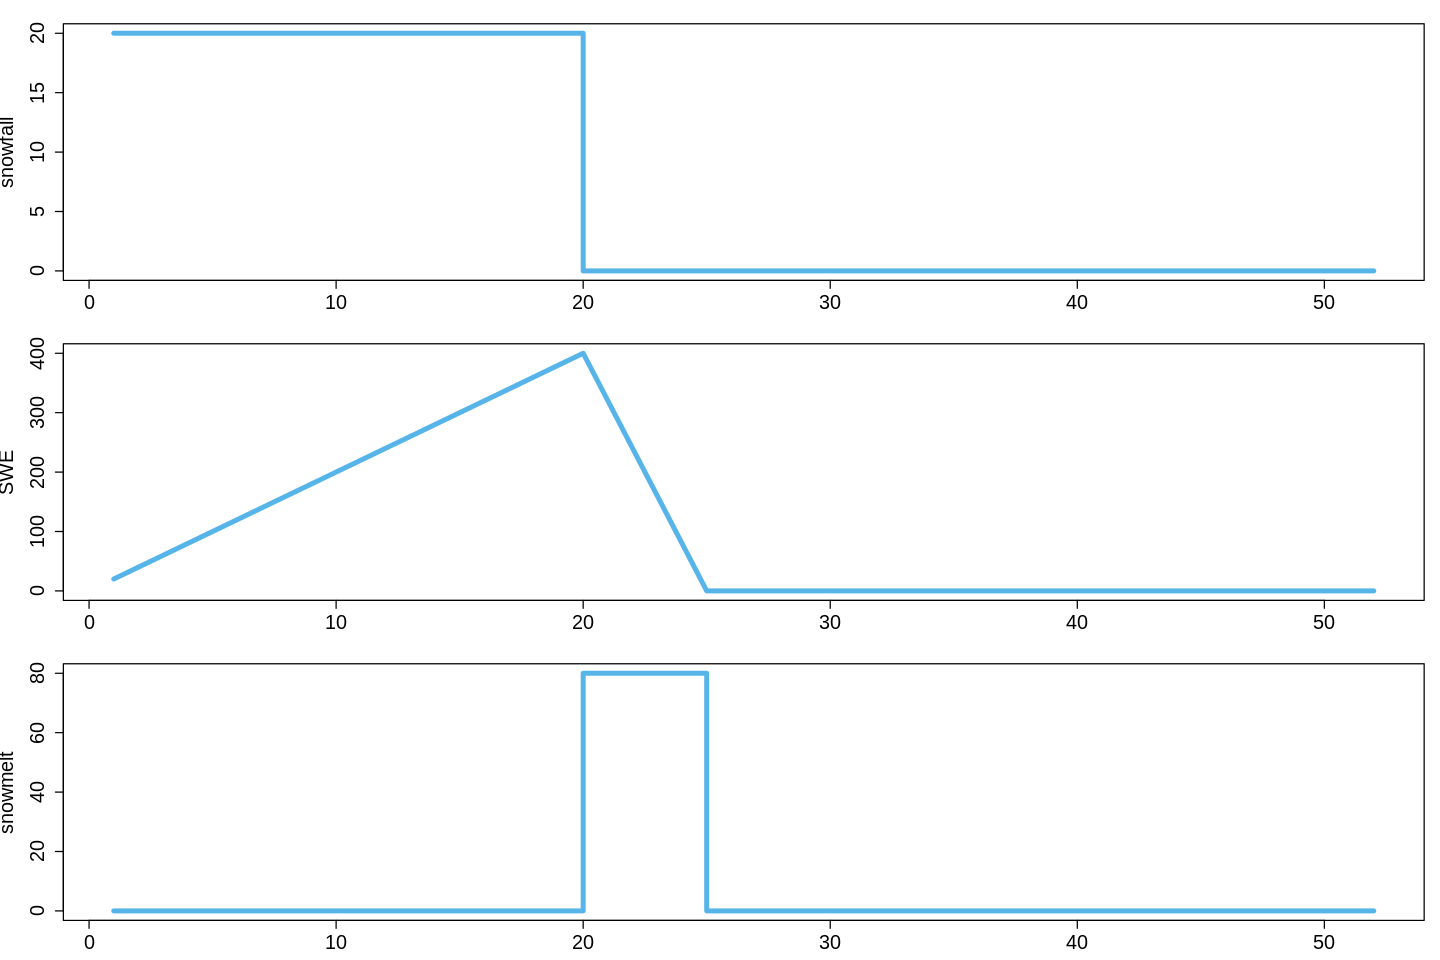

In [6]:
n <- 52
P <- c(rep(20, 20), rep(0, 32))
T <- c(rep(-5, 20), rep(5, 32))

snow_ex <- snow_model(P, T, DDF = 16)

layout(matrix(1:3, ncol = 1))
par(ps = 18, mar = c(2.5, 4, 1.5, 1))

plot(snow_ex$t, snow_ex$snowfall, type = "S", lwd = 4, col = blue,
     xlab = "", ylab = "snowfall")
plot(snow_ex$t, snow_ex$SWE, type = "l", lwd = 4, col = blue,
     xlab = "", ylab = "SWE")
plot(snow_ex$t, snow_ex$melt, type = "S", lwd = 4, col = blue,
     xlab = "time step", ylab = "snowmelt")

## 4. Subsurface storage

After snow melts, liquid water can infiltrate into the soil and be stored in a root-zone or subsurface reservoir. This storage is depleted by runoff and evapotranspiration.

The simplest subsurface water balance is:

$$
S(t+1) = S(t) + I(t) - E(t) - Q(t)
$$

where $I(t)$ is liquid input, such as rainfall or snowmelt.

## 5. Linear runoff and evapotranspiration

In the linear reservoir version, both runoff and evapotranspiration are proportional to storage:

$$
Q = \frac{S}{\tau_Q}
$$

$$
E = \frac{S}{\tau_E}
$$

Small values of $\tau_Q$ produce fast drainage, while large values produce slow runoff recession. Similarly, $\tau_E$ controls how quickly storage is depleted by evapotranspiration.

In [ ]:
linear_storage_model <- function(
    input,
    tau_Q = 10,
    tau_E = 20,
    S_0 = 0
) {
  n <- length(input)

  S <- rep(NA, n + 1)
  Q <- rep(NA, n)
  E <- rep(NA, n)

  S[1] <- S_0

  for (t in 1:n) {
    S_available <- S[t] + input[t]

    Q[t] <- S_available / tau_Q
    E[t] <- S_available / tau_E

    total_out <- Q[t] + E[t]

    if (total_out > S_available) {
      scale <- S_available / total_out
      Q[t] <- Q[t] * scale
      E[t] <- E[t] * scale
    }

    S[t + 1] <- S_available - Q[t] - E[t]
  }

  data.frame(
    t = 1:n,
    input = input,
    S = S[-1],
    Q = Q,
    E = E
  )
}

## 6. Nonlinear storage–flux relationships

Linear reservoirs are useful, but real catchments often respond nonlinearly. Runoff may increase rapidly when the catchment becomes wet, while evapotranspiration may be limited when storage is low and approach potential evapotranspiration when water is available.

We represent this with:

$$
Q(S) = Q_0 \left(\frac{S}{S_b}\right)^d
$$

$$
E(S) = E_p(t) \left(\frac{S}{S_b}\right)^b
$$

where $S_b$ is a reference storage capacity.